# Results Viewer — Post-Hoc Robustness

Loads experiment output from `data/output/results/` and produces the figures and tables below.

**Primary metric:** `calibrated_f1` (F1 at source-validation-optimised threshold).

Run `python src/main.py` first to generate data.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
OUT = Path("../data/output/results")
METRIC = "calibrated_f1"
METRIC_LABEL = "Calibrated F1"
PRIMARY_METHOD = "erm"

In [2]:
result_dirs = sorted(OUT.glob("*/**/probe_results.csv"))
print(f"Found {len(result_dirs)} result file(s):")

all_probe = {}
all_summary = {}
for p in result_dirs:
    key = p.relative_to(OUT).parent.as_posix()
    df = pd.read_csv(p)
    all_probe[key] = df
    # also load summary if present
    sp = p.parent / "summary.csv"
    if sp.exists():
        all_summary[key] = pd.read_csv(sp)
    print(f"  {key}:  probe_results {df.shape[0]} rows × {df.shape[1]} cols")

if not all_probe:
    print("No results found. Run `python src/main.py` first.")

Found 2 result file(s):
  presto/bin-crop-class:  probe_results 50 rows × 27 cols
  presto/pheno-proxy:  probe_results 25 rows × 18 cols


## 1.  Data overview

In [3]:
for key, df in all_probe.items():
    print(f"\n=== {key} ===")
    print(f"  Methods:       {sorted(df['method'].unique())}")
    print(f"  Holdouts:      {sorted(df['holdout'].unique())}")
    print(f"  Conditions:    {sorted(df['condition'].unique())}")
    print(f"  Budgets:       {sorted(df['label_budget'].unique())}")
    print(f"  Seeds:         {sorted(df['seed'].unique())}")
    print(f"  Metric cols:   {[c for c in df.columns if c in ['f1','auc','balanced_accuracy','calibrated_f1','calibrated_balanced_accuracy','ece']]}")
    display(df.head(3))


=== presto/bin-crop-class ===
  Methods:       ['erm']
  Holdouts:      ['ethiopia', 'lem-brazil', 'rwanda', 'togo', 'togo-eval']
  Conditions:    ['clean', 'sensor_off_s2']
  Budgets:       [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.25), np.float64(1.0)]
  Seeds:         [np.int64(42)]
  Metric cols:   ['f1', 'auc', 'balanced_accuracy', 'calibrated_f1', 'calibrated_balanced_accuracy']


,encoder,benchmark,task,method,holdout,condition,train_regime,label_budget,seed,n_train_sub,...,probe_tol,probe_n_iter,probe_converged,probe_convergence_warnings,probe_warning_message,f1,auc,balanced_accuracy,calibrated_f1,calibrated_balanced_accuracy
0,presto,cropharvest,bin-crop-class,erm,togo,clean,clean,0.01,42,53,...,0.00001,7,1,0,NaN,0.693182,0.648429,0.508418,0.706522,0.501684
1,presto,cropharvest,bin-crop-class,erm,togo,clean,clean,0.05,42,265,...,0.00001,7,1,0,NaN,0.729282,0.665264,0.546296,0.725275,0.537037
2,presto,cropharvest,bin-crop-class,erm,togo,clean,clean,0.10,42,529,...,0.00001,9,1,0,NaN,0.114286,0.741863,0.530303,0.370370,0.613636



=== presto/pheno-proxy ===
  Methods:       ['erm']
  Holdouts:      ['Coastal Cauvery', 'Coastal Vennar', 'Lower Cauvery', 'Middle Vennar', 'Upper Cauvery']
  Conditions:    ['clean']
  Budgets:       [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.25), np.float64(1.0)]
  Seeds:         [np.int64(42)]
  Metric cols:   []


,encoder,benchmark,task,method,holdout,condition,train_regime,label_budget,seed,n_train_sub,n_test,probe_solver,ridge_alpha,rmse,mae,r2,pearson_r,spearman_r
0,presto,sickle,pheno-proxy,erm,Coastal Cauvery,clean,clean,0.01,42,6,196,ridge,1.0,36.530796,28.450638,-1.321069,0.109509,0.118117
1,presto,sickle,pheno-proxy,erm,Coastal Cauvery,clean,clean,0.05,42,32,196,ridge,1.0,42.161155,31.801645,-2.091681,0.027642,0.082380
2,presto,sickle,pheno-proxy,erm,Coastal Cauvery,clean,clean,0.10,42,64,196,ridge,1.0,44.910210,32.960537,-2.508003,0.178483,0.161206


## 2.  Aggregate: method × condition at full budget

Calibrated F1 averaged over all holdouts and seeds at 100% label budget.

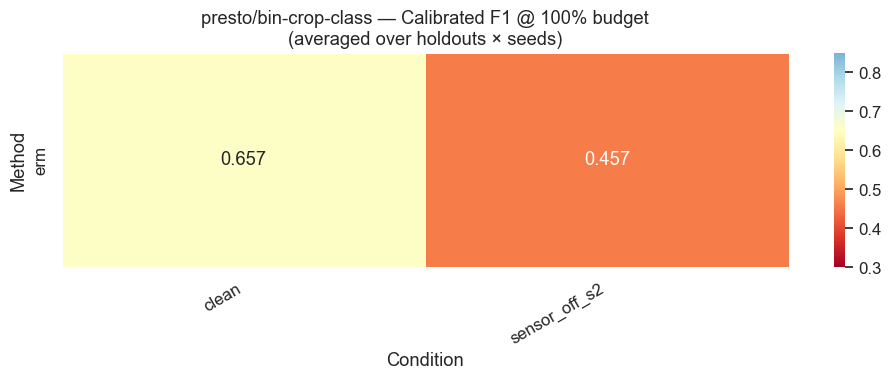

KeyError: 'Column not found: calibrated_f1'

In [4]:
for key, df in all_probe.items():
    full = df[df["label_budget"] == 1.0]
    pivot = full.groupby(["method", "condition"], as_index=False)[METRIC].mean()

    pt = pivot.pivot(index="method", columns="condition", values=METRIC)
    pt = pt.reindex(columns=sorted(pt.columns))

    fig, ax = plt.subplots(figsize=(max(10, len(pt.columns) * 0.6), max(4, len(pt.index) * 0.4)))
    sns.heatmap(pt, annot=True, fmt=".3f", cmap="RdYlBu", center=0.65,
                vmin=0.3, vmax=0.85, linewidths=0.5, ax=ax)
    ax.set_title(f"{key} — {METRIC_LABEL} @ 100% budget\n(averaged over holdouts × seeds)")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Method")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 3.  Label-budget curves

How each method performs as label availability increases (averaged over holdouts and seeds).
Line colour encodes the method; each facet is one stress condition.

In [ ]:
for key, df in all_probe.items():
    grp = df.groupby(["method", "condition", "label_budget"], as_index=False)[METRIC].agg(["mean", "std"]).reset_index()

    conditions = sorted(grp["condition"].unique())
    ncols = 3
    nrows = int(np.ceil(len(conditions) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, cond in zip(axes, conditions):
        sub = grp[grp["condition"] == cond]
        for method in sorted(sub["method"].unique()):
            m = sub[sub["method"] == method]
            ax.errorbar(m["label_budget"], m["mean"], yerr=m["std"],
                        marker="o", capsize=3, label=method, linewidth=1.5)
        ax.set_title(cond, fontsize=11)
        ax.set_xlabel("Label budget")
        if ax.is_first_col():
            ax.set_ylabel(METRIC_LABEL)
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.set_ylim(0.2, 0.9)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(conditions):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels),
               bbox_to_anchor=(0.5, -0.05), fontsize=9)
    fig.suptitle(f"{key} — {METRIC_LABEL} by budget and condition", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

## 4.  Per-holdout method comparison (full budget)

Bar chart of calibrated F1 for each method, grouped by holdout region, at 100% labels.

In [ ]:
for key, df in all_probe.items():
    full = df[df["label_budget"] == 1.0]
    grp = full.groupby(["method", "holdout"], as_index=False)[METRIC].agg(["mean", "std"]).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.barplot(data=grp, x="holdout", y="mean", hue="method",
                capsize=0.05, errwidth=1, ax=ax)
    ax.set_title(f"{key} — {METRIC_LABEL} by holdout @ 100% budget")
    ax.set_xlabel("Holdout region")
    ax.set_ylabel(METRIC_LABEL)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## 5.  Condition impact — degradation relative to `clean`

Shows the drop (or gain) in calibrated F1 for each corruption condition relative to the clean baseline.
Negative values mean the condition hurts performance.

In [ ]:
for key, df in all_probe.items():
    full = df[df["label_budget"] == 1.0]
    clean = full[full["condition"] == "clean"][["method", "holdout", "seed", METRIC]].rename(
        columns={METRIC: "clean_score"})
    merged = full.merge(clean, on=["method", "holdout", "seed"], how="left")
    merged["delta"] = merged[METRIC + "_x"] - merged["clean_score"]

    delta = merged.groupby(["method", "condition"], as_index=False)["delta"].mean()

    pt = delta.pivot(index="method", columns="condition", values="delta")
    pt = pt.reindex(columns=sorted(pt.columns))

    fig, ax = plt.subplots(figsize=(max(10, len(pt.columns) * 0.6), max(4, len(pt.index) * 0.4)))
    sns.heatmap(pt, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                vmin=-0.25, vmax=0.25, linewidths=0.5, ax=ax)
    ax.set_title(f"{key} — Δ{METRIC_LABEL} relative to clean @ 100% budget")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Method")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 6.  GRIT vs ERM — relative improvement

How much better (or worse) each GRIT variant performs compared to the ERM baseline at each budget level.

In [ ]:
for key, df in all_probe.items():
    erm = df[df["method"] == PRIMARY_METHOD][["condition", "holdout", "seed", "label_budget", METRIC]].rename(
        columns={METRIC: "erm_score"})
    grit = df[df["method"].str.startswith("grit")]
    merged = grit.merge(erm, on=["condition", "holdout", "seed", "label_budget"])
    merged["improvement"] = merged[METRIC + "_x"] - merged["erm_score"]

    grp = merged.groupby(["method", "label_budget"], as_index=False)["improvement"].agg(["mean", "std"]).reset_index()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for method in sorted(grp["method"].unique()):
        m = grp[grp["method"] == method]
        ax.errorbar(m["label_budget"], m["mean"], yerr=m["std"],
                    marker="o", capsize=3, label=method, linewidth=1.5)

    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xlabel("Label budget")
    ax.set_ylabel(f"Δ{METRIC_LABEL} vs {PRIMARY_METHOD.upper()}")
    ax.set_title(f"{key} — GRIT improvement over {PRIMARY_METHOD.upper()}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7.  Best / worst conditions for each method

Ranks conditions by (calibrated F1) for each method at 100% budget.

In [ ]:
for key, df in all_probe.items():
    full = df[df["label_budget"] == 1.0]
    ranking = full.groupby(["method", "condition"], as_index=False)[METRIC].mean()
    # best 3 and worst 3 per method
    tops = ranking.groupby("method").apply(
        lambda g: g.nlargest(3, METRIC)[["condition", METRIC]].reset_index(drop=True)).reset_index()
    bottoms = ranking.groupby("method").apply(
        lambda g: g.nsmallest(3, METRIC)[["condition", METRIC]].reset_index(drop=True)).reset_index()

    print(f"\n=== {key}: Best 3 conditions (highest {METRIC_LABEL}) ===")
    display(tops)
    print(f"\n=== {key}: Worst 3 conditions (lowest {METRIC_LABEL}) ===")
    display(bottoms)

## 8.  Summary table (full budget, averaged)

Pivoted table of calibrated F1: rows = method, columns = condition.

In [ ]:
for key, df in all_probe.items():
    full = df[df["label_budget"] == 1.0]
    pivot = full.groupby(["method", "condition"], as_index=False)[METRIC].mean()
    pt = pivot.pivot(index="method", columns="condition", values=METRIC)
    pt = pt.reindex(columns=sorted(pt.columns))
    pt["avg"] = pt.mean(axis=1)
    display(pt.style.format("{:.3f}").background_gradient(cmap="RdYlBu", axis=None))
    safe_key = key.replace("/", "_")
    out_path = OUT / f"{safe_key}_summary_table.csv"
    pt.to_csv(out_path)
    print(f"Saved to {out_path}")

## 9.  Full result table by budget

Method × condition averaged over holdouts, for each budget level.

In [ ]:
for key, df in all_probe.items():
    for budget in sorted(df["label_budget"].unique()):
        sub = df[df["label_budget"] == budget]
        pivot = sub.groupby(["method", "condition"], as_index=False)[METRIC].mean()
        pt = pivot.pivot(index="method", columns="condition", values=METRIC)
        pt = pt.reindex(columns=sorted(pt.columns))
        pt["avg"] = pt.mean(axis=1)
        print(f"\nBudget: {budget:.0%}")
        display(pt.style.format("{:.3f}").background_gradient(cmap="RdYlBu", axis=None))

---
*Add more result directories under `data/output/results/` (e.g. other encoders, tasks) and re-run all cells to compare.*